# INTELLIGENT SYSTEM DEVELOPMENT - ASSIGNMENT 03

## Ứng dụng 3: Customer Behavior / Interest Discovery

**Dataset:** Synthetic E-Commerce Customer Behavior Dataset  
**Target:** `is_churned`  
**Bài toán:** Binary Classification  
**Mục tiêu:** Dự đoán churn và diễn giải interest thông qua transaction, session, product và review features.

---

### 1. Định nghĩa bài toán

- **Đầu vào:** customer profile, RFM, session funnel, category/brand preference và review text.
- **Đầu ra:** xác suất churn `0/1`.
- **Đánh giá:** so sánh 5 mô hình ML với Improved DNN. DL baseline của giảng viên được trình bày riêng.


---

### 2. Thiết lập môi trường

Import thư viện và helper cho relational data, tabular preprocessing và text preprocessing.


In [1]:
from pathlib import Path
from datetime import datetime, timezone
import json
import joblib
import math
import re
import warnings

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

try:
    from IPython.display import display
except ImportError:

    def display(obj=None):
        if obj is not None:
            print(obj)


try:
    import matplotlib.pyplot as plt

    HAS_MATPLOTLIB = True
except ImportError:
    HAS_MATPLOTLIB = False

    class _NoPlotAxis:
        def __getattr__(self, name):
            def _method(*args, **kwargs):
                return self

            return _method

    class _NoPlotAxes(list):
        def ravel(self):
            return self

    class _NoPlot:
        def figure(self, *args, **kwargs):
            print("Matplotlib is not installed; plot skipped.")
            return _NoPlotAxis()

        def subplots(self, nrows=1, ncols=1, *args, **kwargs):
            print("Matplotlib is not installed; plot skipped.")
            fig = _NoPlotAxis()
            if nrows == 1 and ncols == 1:
                return fig, _NoPlotAxis()
            axes = _NoPlotAxes([_NoPlotAxis() for _ in range(nrows * ncols)])
            return fig, axes

        def __getattr__(self, name):
            def _method(*args, **kwargs):
                return _NoPlotAxis()

            return _method

    plt = _NoPlot()

from sklearn.base import clone
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.dummy import DummyClassifier, DummyRegressor
from sklearn.ensemble import (
    GradientBoostingClassifier,
    GradientBoostingRegressor,
    RandomForestClassifier,
    RandomForestRegressor,
)
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    confusion_matrix,
    f1_score,
    mean_absolute_error,
    mean_squared_error,
    precision_score,
    r2_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, OneHotEncoder, StandardScaler
from sklearn.svm import LinearSVC
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor

SEED = 42
np.random.seed(SEED)

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 140)


def find_project_root(start=None):
    start = Path.cwd() if start is None else Path(start)
    candidates = [start, *start.parents]
    for candidate in candidates:
        if (candidate / "datasets").exists() and (candidate / "pipeline").exists():
            return candidate
    return start


ROOT = find_project_root()
DATA_DIR = ROOT / "datasets"
ARTIFACT_DIR = ROOT / "artifacts"

print("Project root:", ROOT)


def display_df(title, df, rows=10):
    print(title)
    display(df.head(rows))


def missing_table(df):
    result = pd.DataFrame(
        {
            "missing_count": df.isna().sum(),
            "missing_pct": df.isna().mean().mul(100).round(2),
            "dtype": df.dtypes.astype(str),
            "n_unique": df.nunique(dropna=True),
        }
    )
    return result.sort_values(["missing_pct", "missing_count"], ascending=False)


def iqr_outlier_table(df, columns):
    rows = []
    for col in columns:
        s = pd.to_numeric(df[col], errors="coerce").dropna()
        if s.empty:
            continue
        q1, q3 = s.quantile([0.25, 0.75])
        iqr = q3 - q1
        lo = q1 - 1.5 * iqr
        hi = q3 + 1.5 * iqr
        rows.append(
            {
                "feature": col,
                "min": s.min(),
                "q1": q1,
                "median": s.median(),
                "q3": q3,
                "max": s.max(),
                "iqr_lower": lo,
                "iqr_upper": hi,
                "outlier_count": int(((s < lo) | (s > hi)).sum()),
                "outlier_pct": round(((s < lo) | (s > hi)).mean() * 100, 2),
            }
        )
    return pd.DataFrame(rows)


def make_one_hot_encoder(**kwargs):
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=True, **kwargs)
    except TypeError:
        try:
            return OneHotEncoder(handle_unknown="ignore", sparse=True, **kwargs)
        except TypeError:
            legacy_kwargs = {
                k: v
                for k, v in kwargs.items()
                if k not in {"min_frequency", "max_categories"}
            }
            return OneHotEncoder(handle_unknown="ignore", sparse=True, **legacy_kwargs)


def to_dense_array(matrix):
    if hasattr(matrix, "toarray"):
        matrix = matrix.toarray()
    return np.asarray(matrix, dtype=np.float32)


def dense_transformer():
    return FunctionTransformer(to_dense_array, accept_sparse=True, validate=False)


def assert_no_nan_inf(matrix, name):
    values = matrix.data if hasattr(matrix, "data") else np.asarray(matrix)
    assert np.isfinite(values).all(), f"{name} contains NaN or Inf"
    print(f"{name}: shape={matrix.shape}, finite_values=OK")


from collections import Counter

from sklearn.feature_extraction.text import TfidfVectorizer


def simple_tokenize(text):
    return re.findall(r"[a-zA-Z']+", str(text).lower())


def top_value(series):
    values = series.dropna().astype(str)
    if values.empty:
        return "Unknown"
    return values.value_counts().idxmax()


def safe_divide(num, den):
    return np.where(np.asarray(den) == 0, 0, np.asarray(num) / np.asarray(den))

Project root: c:\DATA\assign


---

### 3. Nạp dữ liệu

Nạp các bảng customers, products, transactions, sessions và reviews.


In [2]:
CUSTOMER_DIR = DATA_DIR / "customer_behavior"
paths = {
    "customers": CUSTOMER_DIR / "customers.csv",
    "products": CUSTOMER_DIR / "products.csv",
    "transactions": CUSTOMER_DIR / "transactions.csv",
    "sessions": CUSTOMER_DIR / "sessions.csv",
    "reviews": CUSTOMER_DIR / "reviews.csv",
}
for name, path in paths.items():
    assert path.exists(), f"Missing {name}: {path}"

customers_raw = pd.read_csv(paths["customers"])
products_raw = pd.read_csv(paths["products"])
transactions_raw = pd.read_csv(paths["transactions"])
sessions_raw = pd.read_csv(paths["sessions"])
reviews_raw = pd.read_csv(paths["reviews"])

customer_tables = {
    "customers": customers_raw,
    "products": products_raw,
    "transactions": transactions_raw,
    "sessions": sessions_raw,
    "reviews": reviews_raw,
}

overview = []
for name, df in customer_tables.items():
    overview.append(
        {
            "table": name,
            "rows": len(df),
            "columns": df.shape[1],
            "missing_cells": int(df.isna().sum().sum()),
            "duplicate_rows": int(df.duplicated().sum()),
        }
    )
display(pd.DataFrame(overview))
display(customers_raw.head())

,table,rows,columns,missing_cells,duplicate_rows
0,customers,10000,10,0,0
1,products,1000,11,0,0
2,transactions,120000,11,0,0
3,sessions,80000,10,0,0
4,reviews,25000,8,0,0


,customer_id,signup_date,age,gender,country,segment,is_churned,lifetime_value,email_opt_in,has_app
0,C00000,2020-02-13,28,M,BR,Premium,0,1595.27,0,0
1,C00001,2021-10-01,22,Prefer not to say,FR,Regular,0,1160.61,1,0
2,C00002,2022-06-26,30,F,US,VIP,0,3093.32,1,1
3,C00003,2021-12-21,48,F,US,Premium,1,2131.08,1,0
4,C00004,2021-09-16,37,M,CA,Budget Shopper,0,583.39,0,1


**Nhận xét.** Dữ liệu gồm 10,000 customers, 1,000 products, 120,000 transactions, 80,000 sessions và 25,000 reviews. Vì target ở cấp customer, các bảng hành vi phải aggregate về `customer_id` trước modeling.


---

### 4. Kiểm tra chất lượng dữ liệu

Kiểm tra missing values, duplicates, ID-only columns, orphan keys và categorical consistency.


In [3]:
for name, df in customer_tables.items():
    print(f"\n{name.upper()} dtypes")
    display(df.dtypes.to_frame("dtype").T)
    display(missing_table(df).head(12))

customer_ids = set(customers_raw["customer_id"])
product_ids = set(products_raw["product_id"])
key_report = {
    "transactions_unknown_customer": int(
        (~transactions_raw["customer_id"].isin(customer_ids)).sum()
    ),
    "sessions_unknown_customer": int(
        (~sessions_raw["customer_id"].isin(customer_ids)).sum()
    ),
    "reviews_unknown_customer": int(
        (~reviews_raw["customer_id"].isin(customer_ids)).sum()
    ),
    "transactions_unknown_product": int(
        (~transactions_raw["product_id"].isin(product_ids)).sum()
    ),
    "reviews_unknown_product": int(
        (~reviews_raw["product_id"].isin(product_ids)).sum()
    ),
}
print(json.dumps(key_report, indent=2, ensure_ascii=False))

for col in ["gender", "country", "segment"]:
    print(f"\nCustomer category - {col}")
    display(customers_raw[col].value_counts(dropna=False).to_frame("count"))


CUSTOMERS dtypes


,customer_id,signup_date,age,gender,country,segment,is_churned,lifetime_value,email_opt_in,has_app
dtype,str,str,int64,str,str,str,int64,float64,int64,int64


,missing_count,missing_pct,dtype,n_unique
customer_id,0,0.0,str,10000
signup_date,0,0.0,str,1714
age,0,0.0,int64,58
gender,0,0.0,str,4
country,0,0.0,str,10
segment,0,0.0,str,5
is_churned,0,0.0,int64,2
lifetime_value,0,0.0,float64,9781
email_opt_in,0,0.0,int64,2
has_app,0,0.0,int64,2



PRODUCTS dtypes


,product_id,product_name,category,brand,price,avg_rating,num_ratings,stock_quantity,discount_pct,is_featured,weight_kg
dtype,str,str,str,str,float64,float64,int64,int64,int64,int64,float64


...

,count
gender,
F,4563
M,4466
Prefer not to say,495
Non-binary,476



Customer category - country


,count
country,
US,3933
UK,1186
CA,1032
DE,760
AU,618
FR,614
IN,603
BR,529
JP,433



Customer category - segment


,count
segment,
Regular,3500
Budget Shopper,3043
Premium,1982
VIP,974
Occasional Visitor,501


**Nhận xét.** Orphan key bằng 0 ở transaction, session và review, nên các khóa join nhất quán. ID columns chỉ dùng để join, còn `lifetime_value` bị loại để tránh leakage.


---

### 5. Prediction-time boundary

Prediction time đặt 90 ngày trước event cuối cùng. Features chỉ dùng dữ liệu trước cutoff.


In [4]:
customers = customers_raw.copy()
products = products_raw.copy()
transactions = transactions_raw.copy()
sessions = sessions_raw.copy()
reviews = reviews_raw.copy()

customers["signup_date"] = pd.to_datetime(customers["signup_date"], errors="coerce")
transactions["transaction_date"] = pd.to_datetime(
    transactions["transaction_date"], errors="coerce"
)
sessions["session_date"] = pd.to_datetime(sessions["session_date"], errors="coerce")
reviews["review_date"] = pd.to_datetime(reviews["review_date"], errors="coerce")

latest_event_date = max(
    transactions["transaction_date"].max(),
    sessions["session_date"].max(),
    reviews["review_date"].max(),
)
PREDICTION_CUTOFF = latest_event_date - pd.Timedelta(days=90)
OBSERVATION_START = min(
    transactions["transaction_date"].min(),
    sessions["session_date"].min(),
    reviews["review_date"].min(),
)
OBSERVATION_WINDOW_DAYS = int((PREDICTION_CUTOFF - OBSERVATION_START).days) + 1
NO_ACTIVITY_RECENCY_DAYS = OBSERVATION_WINDOW_DAYS + 30

transactions_obs = transactions[
    transactions["transaction_date"] <= PREDICTION_CUTOFF
].copy()
sessions_obs = sessions[sessions["session_date"] <= PREDICTION_CUTOFF].copy()
reviews_obs = reviews[reviews["review_date"] <= PREDICTION_CUTOFF].copy()

print("Latest event date:", latest_event_date)
print("Prediction cutoff:", PREDICTION_CUTOFF)
print("Observation window days:", OBSERVATION_WINDOW_DAYS)
print("Rows kept before cutoff:")
display(
    pd.DataFrame(
        {
            "table": ["transactions", "sessions", "reviews"],
            "original_rows": [len(transactions), len(sessions), len(reviews)],
            "pre_cutoff_rows": [
                len(transactions_obs),
                len(sessions_obs),
                len(reviews_obs),
            ],
        }
    )
)

Latest event date: 2024-12-30 23:59:05
Prediction cutoff: 2024-10-01 23:59:05
Observation window days: 640
Rows kept before cutoff:


,table,original_rows,pre_cutoff_rows
0,transactions,120000,105502
1,sessions,80000,70139
2,reviews,25000,21848


**Nhận xét.** Event cuối cùng là 2024-12-30 23:59:05, cutoff đặt tại 2024-10-01 23:59:05. Sau cutoff có 14,498 transactions, 9,861 sessions và 3,152 reviews bị loại khỏi feature engineering.


---

### 6. Phân tích target

Kiểm tra class balance của `is_churned`.


,count,pct
is_churned,,
0,8306,83.06
1,1694,16.94


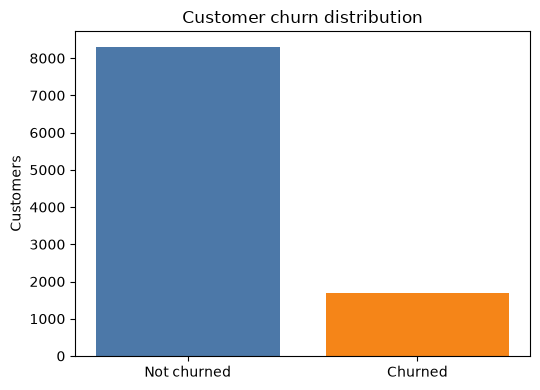

In [5]:
CUSTOMER_TARGET = "is_churned"
customers[CUSTOMER_TARGET] = customers[CUSTOMER_TARGET].astype(int)

churn_counts = customers[CUSTOMER_TARGET].value_counts().sort_index()
churn_pct = (
    customers[CUSTOMER_TARGET]
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .round(2)
)
display(pd.DataFrame({"count": churn_counts, "pct": churn_pct}))

plt.figure(figsize=(5.5, 4))
plt.bar(["Not churned", "Churned"], churn_counts.values, color=["#4C78A8", "#F58518"])
plt.title("Customer churn distribution")
plt.ylabel("Customers")
plt.tight_layout()
plt.show()

**Nhận xét.** Target mất cân bằng rõ: 8,306 khách không churn (83.06%) và 1,694 khách churn (16.94%). Vì vậy Accuracy dễ gây hiểu nhầm; F1/Recall/Precision quan trọng hơn.


---

### 7. Customer-level feature engineering

Tạo RFM/spending, transaction status, session funnel, preference, rating và review text features.


In [6]:
tx_prod = transactions_obs.merge(
    products[["product_id", "category", "brand"]],
    on="product_id",
    how="left",
)
completed_tx = tx_prod[tx_prod["status"] == "completed"].copy()

tx_basic = tx_prod.groupby("customer_id").agg(
    total_transactions=("transaction_id", "count"),
    total_quantity=("quantity", "sum"),
    avg_discount=("discount_applied", "mean"),
    avg_shipping_cost=("shipping_cost", "mean"),
    last_transaction_date=("transaction_date", "max"),
)

status_counts = tx_prod.pivot_table(
    index="customer_id",
    columns="status",
    values="transaction_id",
    aggfunc="count",
    fill_value=0,
).rename(columns=lambda c: f"{c}_transactions")

tx_completed = completed_tx.groupby("customer_id").agg(
    completed_orders=("transaction_id", "count"),
    total_spent=("total_amount", "sum"),
    avg_order_value=("total_amount", "mean"),
    category_diversity=("category", "nunique"),
    brand_diversity=("brand", "nunique"),
    top_category=("category", top_value),
    top_brand=("brand", top_value),
)

top_categories = completed_tx["category"].value_counts().head(8).index.tolist()
category_spend = (
    completed_tx[completed_tx["category"].isin(top_categories)]
    .pivot_table(
        index="customer_id",
        columns="category",
        values="total_amount",
        aggfunc="sum",
        fill_value=0,
    )
    .rename(
        columns=lambda c: f"spend_category_{re.sub(r'[^A-Za-z0-9]+', '_', str(c)).strip('_').lower()}"
    )
)

tx_features = (
    tx_basic.join(status_counts, how="outer")
    .join(tx_completed, how="outer")
    .join(category_spend, how="outer")
)

session_features = sessions_obs.groupby("customer_id").agg(
    session_count=("session_id", "count"),
    avg_session_duration=("duration_seconds", "mean"),
    total_pages_viewed=("pages_viewed", "sum"),
    avg_pages_viewed=("pages_viewed", "mean"),
    conversion_rate=("converted", "mean"),
    bounce_rate=("bounced", "mean"),
    cart_additions_total=("cart_additions", "sum"),
    cart_additions_avg=("cart_additions", "mean"),
    device_diversity=("device", "nunique"),
    channel_diversity=("channel", "nunique"),
    top_device=("device", top_value),
    top_channel=("channel", top_value),
    last_session_date=("session_date", "max"),
)

reviews_obs["review_text_clean"] = (
    reviews_obs["review_text"].fillna("").astype(str).str.lower()
)
review_features = reviews_obs.groupby("customer_id").agg(
    review_count=("review_id", "count"),
    avg_rating=("rating", "mean"),
    low_rating_share=("rating", lambda s: (s <= 2).mean()),
    verified_review_share=("verified_purchase", "mean"),
    helpful_votes_total=("helpful_votes", "sum"),
    review_text_all=("review_text_clean", lambda s: " ".join(s.dropna().astype(str))),
    last_review_date=("review_date", "max"),
)

customer_features = (
    customers.drop(columns=["lifetime_value"])
    .set_index("customer_id")
    .join(
        [tx_features, session_features, review_features],
        how="left",
    )
)

customer_features["customer_tenure_days"] = (
    PREDICTION_CUTOFF - customer_features["signup_date"]
).dt.days.clip(lower=0)
customer_features["days_since_last_transaction"] = (
    PREDICTION_CUTOFF - customer_features["last_transaction_date"]
).dt.days
customer_features["days_since_last_session"] = (
    PREDICTION_CUTOFF - customer_features["last_session_date"]
).dt.days
customer_features["days_since_last_review"] = (
    PREDICTION_CUTOFF - customer_features["last_review_date"]
).dt.days

customer_features = customer_features.reset_index()
display(customer_features.head())
print("Customer feature table shape:", customer_features.shape)

,customer_id,signup_date,age,gender,country,segment,is_churned,email_opt_in,has_app,total_transactions,total_quantity,avg_discount,avg_shipping_cost,last_transaction_date,cancelled_transactions,completed_transactions,pending_transactions,refunded_transactions,completed_orders,total_spent,avg_order_value,category_diversity,brand_diversity,top_category,top_brand,spend_category_clothing,spend_category_electronics,spend_category_food_grocery,spend_category_health,spend_category_jewelry,spend_category_office_supplies,spend_category_pet_supplies,spend_category_sports,session_count,avg_session_duration,total_pages_viewed,avg_pages_viewed,conversion_rate,bounce_rate,cart_additions_total,cart_additions_avg,device_diversity,channel_diversity,top_device,top_channel,last_session_date,review_count,avg_rating,low_rating_share,verified_review_share,helpful_votes_total,review_text_all,last_review_date,customer_tenure_days,days_since_last_transaction,days_since_last_session,days_since_last_review
0,C00000,2020-02-13,28,M,BR,Premium,0,0,0,22.0,29.0,5.227273,5.260455,2024-09-27 18:11:32,2.0,15.0,2.0,3.0,15.0,649.36,43.290667,8.0,11.0,Music,NovaTech,55.96,218.44,16.42,29.17,0.00,0.0,0.00,0.00,8.0,696.875000,86.0,10.750000,0.125000,0.125000,5.0,0.625000,3.0,5.0,mobile,social,2024-08-21 02:49:48,NaN,NaN,NaN,NaN,NaN,NaN,NaT,1692,4.0,41.0,NaN
1,C00001,2021-10-01,22,Prefer not to say,FR,Regular,0,1,0,10.0,20.0,10.000000,3.304000,2024-09-05 15:11:34,3.0,3.0,4.0,0.0,3.0,158.70,52.900000,3.0,3.0,Health,PureBrand,0.00,0.00,5.61,134.97,0.00,0.0,0.00,0.00,11.0,343.272727,81.0,7.363636,0.000000,0.090909,4.0,0.363636,3.0,5.0,mobile,paid_search,2024-09-06 19:49:55,1.0,2.0,1.0,1.0,41.0,would not recommend. poor value.,2023-05-05,1096,26.0,25.0,515.0
2,C00002,2022-06-26,30,F,US,VIP,0,1,1,27.0,33.0,5.370370,4.856667,2024-09-14 20:24:39,3.0,16.0,5.0,3.0,16.0,1104.66,69.041250,10.0,12.0,Sports,NovaTech,73.08,520.45,0.00,106.73,103.11,0.0,32.04,116.24,27.0,385.925926,182.0,6.740741,0.111111,0.074074,29.0,1.074074,3.0,6.0,mobile,paid_search,2024-08-12 07:28:49,2.0,2.5,0.5,0.5,42.0,decent product for the price. would not recomm...,2024-02-25,828,17.0,50.0,219.0
3,C00003,2021-12-21,48,F,US,Premium,1,1,0,24.0,38.0,8.750000,4.710833,2024-09-23 18:37:53,2.0,14.0,2.0,6.0,14.0,679.05,48.503571,7.0,10.0,Pet Supplies,WorkSmart,324.90,0.00,93.11,0.00,0.00,0.0,92.74,19.87,16.0,298.312500,87.0,5.437500,0.125000,0.187500,18.0,1.125000,3.0,5.0,mobile,paid_search,2024-09-26 00:58:57,1.0,4.0,0.0,1.0,25.0,love it! exactly what i needed.,2023-12-17,1015,8.0,5.0,289.0
4,C00004,2021-09-16,37,M,CA,Budget Shopper,0,0,1,4.0,4.0,6.250000,4.827500,2024-04-17 04:55:28,0.0,2.0,2.0,0.0,2.0,148.32,74.160000,2.0,1.0,Food & Grocery,EcoLiving,0.00,0.00,14.80,0.00,133.52,0.0,0.00,0.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaT,1111,167.0,NaN,NaN


Customer feature table shape: (10000, 57)


**Nhận xét.** Sau cutoff vẫn giữ được 105,502 transactions, 70,139 sessions và 21,848 reviews để tạo feature. Feature table có 10,000 khách và 57 cột trước khi chọn X.


---

### 8. Missing sau aggregation

Điền missing theo ý nghĩa dữ liệu: 0 cho absence, sentinel lớn cho recency, `Unknown` cho categorical và chuỗi rỗng cho text.


In [7]:
category_spend_features = [
    c for c in customer_features.columns if c.startswith("spend_category_")
]

CUSTOMER_NUMERIC_FEATURES = [
    "age",
    "email_opt_in",
    "has_app",
    "customer_tenure_days",
    "total_transactions",
    "total_quantity",
    "avg_discount",
    "avg_shipping_cost",
    "completed_orders",
    "total_spent",
    "avg_order_value",
    "category_diversity",
    "brand_diversity",
    "cancelled_transactions",
    "completed_transactions",
    "pending_transactions",
    "refunded_transactions",
    "session_count",
    "avg_session_duration",
    "total_pages_viewed",
    "avg_pages_viewed",
    "conversion_rate",
    "bounce_rate",
    "cart_additions_total",
    "cart_additions_avg",
    "device_diversity",
    "channel_diversity",
    "review_count",
    "avg_rating",
    "low_rating_share",
    "verified_review_share",
    "helpful_votes_total",
    "days_since_last_transaction",
    "days_since_last_session",
    "days_since_last_review",
] + category_spend_features

CUSTOMER_CATEGORICAL_FEATURES = [
    "gender",
    "country",
    "segment",
    "top_category",
    "top_brand",
    "top_device",
    "top_channel",
]
CUSTOMER_TEXT_FEATURE = "review_text_all"
CUSTOMER_FEATURES = (
    CUSTOMER_NUMERIC_FEATURES + CUSTOMER_CATEGORICAL_FEATURES + [CUSTOMER_TEXT_FEATURE]
)

for col in CUSTOMER_NUMERIC_FEATURES:
    if col not in customer_features.columns:
        customer_features[col] = 0

count_like = [
    c
    for c in CUSTOMER_NUMERIC_FEATURES
    if any(
        token in c
        for token in [
            "count",
            "total",
            "orders",
            "transactions",
            "quantity",
            "spent",
            "votes",
            "spend_category",
        ]
    )
]
rate_like = [
    c for c in CUSTOMER_NUMERIC_FEATURES if c.endswith("_rate") or c.endswith("_share")
]
diversity_like = [c for c in CUSTOMER_NUMERIC_FEATURES if c.endswith("_diversity")]
amount_like = [
    "avg_discount",
    "avg_shipping_cost",
    "avg_order_value",
    "avg_session_duration",
    "avg_pages_viewed",
    "cart_additions_avg",
    "avg_rating",
]
recency_like = [
    "days_since_last_transaction",
    "days_since_last_session",
    "days_since_last_review",
]

zero_fill_cols = sorted(set(count_like + rate_like + diversity_like + amount_like))
customer_features[zero_fill_cols] = customer_features[zero_fill_cols].fillna(0)
customer_features[recency_like] = customer_features[recency_like].fillna(
    NO_ACTIVITY_RECENCY_DAYS
)

for col in CUSTOMER_CATEGORICAL_FEATURES:
    customer_features[col] = customer_features[col].fillna("Unknown").astype(str)
customer_features[CUSTOMER_TEXT_FEATURE] = (
    customer_features[CUSTOMER_TEXT_FEATURE].fillna("").astype(str)
)

customer_model_df = customer_features[CUSTOMER_FEATURES + [CUSTOMER_TARGET]].copy()

display(missing_table(customer_model_df).head(20))
print("Feature count:", len(CUSTOMER_FEATURES))
print(
    "Numeric:",
    len(CUSTOMER_NUMERIC_FEATURES),
    "Categorical:",
    len(CUSTOMER_CATEGORICAL_FEATURES),
    "Text:",
    1,
)

,missing_count,missing_pct,dtype,n_unique
age,0,0.0,int64,58
email_opt_in,0,0.0,int64,2
has_app,0,0.0,int64,2
customer_tenure_days,0,0.0,int64,1653
total_transactions,0,0.0,float64,43
total_quantity,0,0.0,float64,67
avg_discount,0,0.0,float64,766
avg_shipping_cost,0,0.0,float64,8002
completed_orders,0,0.0,float64,28
total_spent,0,0.0,float64,9148


Feature count: 51
Numeric: 43 Categorical: 7 Text: 1


**Nhận xét.** Feature matrix cuối có 51 feature: 43 numeric, 7 categorical và 1 text feature. Các cột ID, raw date và `lifetime_value` không đi vào X.


---

### 9. Behavioral EDA by churn

So sánh RFM, funnel và review metrics theo churn.


total_spent          completed_orders        avg_order_value          session_count        conversion_rate        bounce_rate  \
                  mean   median             mean median            mean   median          mean median            mean median        mean   
is_churned                                                                                                                                 
0           491.184541  371.245         6.416566    6.0       74.928947  61.5825      7.441368    6.0        0.085151    0.0    0.103679   
1           316.111275  214.780         4.164699    4.0       70.372538  55.9050      4.917946    4.0        0.061340    0.0    0.128643   

                  avg_rating           days_since_last_transaction         
           median       mean    median                        mean median  
is_churned                                                                 
0             0.0   2.961148  3.000000                   78.282928   43.0  
1             0.0   2.953956  3.154762                  119.508855   68.0

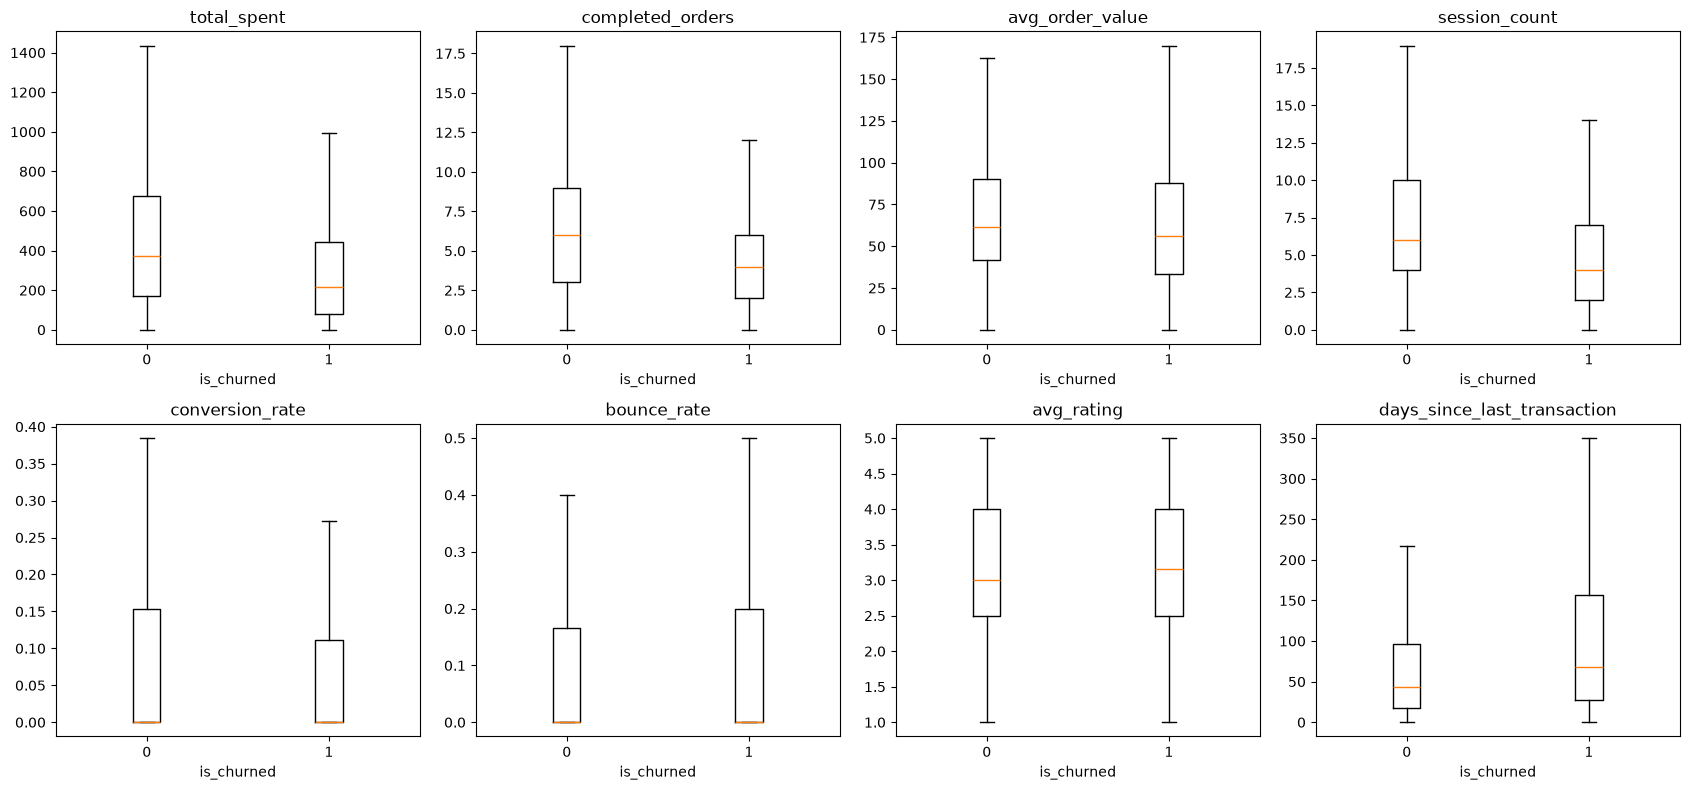

In [8]:
behavior_cols = [
    "total_spent",
    "completed_orders",
    "avg_order_value",
    "session_count",
    "conversion_rate",
    "bounce_rate",
    "avg_rating",
    "days_since_last_transaction",
]

churn_behavior = customer_model_df.groupby(CUSTOMER_TARGET)[behavior_cols].agg(
    ["mean", "median"]
)
display(churn_behavior)

fig, axes = plt.subplots(2, 4, figsize=(17, 8))
axes = axes.ravel()
for ax, col in zip(axes, behavior_cols):
    data0 = customer_model_df.loc[customer_model_df[CUSTOMER_TARGET] == 0, col].dropna()
    data1 = customer_model_df.loc[customer_model_df[CUSTOMER_TARGET] == 1, col].dropna()
    ax.boxplot([data0, data1], tick_labels=["0", "1"], showfliers=False)
    ax.set_title(col)
    ax.set_xlabel("is_churned")
plt.tight_layout()
plt.show()

**Nhận xét.** Nhóm không churn có mean `total_spent` 491.185 và `completed_orders` 6.417; nhóm churn chỉ đạt 316.111 và 4.165. `days_since_last_transaction` của churn cao hơn nhiều (119.509 ngày so với 78.283 ngày).


---

### 10. Interest discovery EDA

Biểu diễn interest bằng category, brand, channel, device và review terms.



Distribution by churn - segment


is_churned,0,1
segment,,
Budget Shopper,27.21,46.22
Regular,35.96,30.28
Occasional Visitor,3.44,12.69
Premium,21.91,9.56
VIP,11.47,1.24



Distribution by churn - top_category


is_churned,0,1
top_category,,
Electronics,8.20,8.15
Health,10.44,8.03
Food & Grocery,7.73,7.67
Jewelry,7.20,7.44
Unknown,2.72,7.08
Home & Garden,6.48,7.02
Pet Supplies,6.90,6.85
Office Supplies,7.37,6.55
Sports,7.22,6.49



Distribution by churn - top_brand


...


Distribution by churn - top_channel


is_churned,0,1
top_channel,,
organic,32.05,28.16
paid_search,21.09,20.19
direct,13.21,12.93
social,13.24,12.81
email,12.05,12.51
referral,6.41,7.97
Unknown,1.95,5.43



Distribution by churn - top_device


is_churned,0,1
top_device,,
mobile,61.55,55.61
desktop,30.38,30.87
tablet,6.13,8.09
Unknown,1.95,5.43


,term,count
0,for,4758
1,not,4749
2,quality,4481
3,the,4361
4,product,3354
5,price,3346
6,great,3337
7,recommend,2938
8,value,2930
9,use,2339


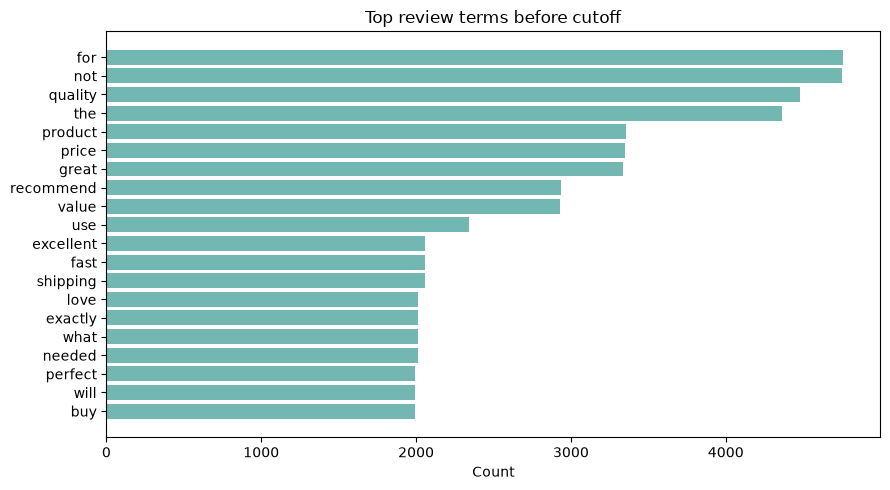

In [9]:
for col in ["segment", "top_category", "top_brand", "top_channel", "top_device"]:
    print(f"\nDistribution by churn - {col}")
    tab = (
        pd.crosstab(
            customer_model_df[col],
            customer_model_df[CUSTOMER_TARGET],
            normalize="columns",
        )
        .mul(100)
        .round(2)
    )
    display(
        tab.sort_values(1, ascending=False).head(12)
        if 1 in tab.columns
        else tab.head(12)
    )

top_terms = Counter()
for text in customer_model_df[CUSTOMER_TEXT_FEATURE].astype(str):
    top_terms.update([t for t in simple_tokenize(text) if len(t) > 2])
top_terms_df = pd.DataFrame(top_terms.most_common(20), columns=["term", "count"])
display(top_terms_df)

plt.figure(figsize=(9, 5))
if not top_terms_df.empty:
    plt.barh(top_terms_df["term"][::-1], top_terms_df["count"][::-1], color="#72B7B2")
plt.title("Top review terms before cutoff")
plt.xlabel("Count")
plt.tight_layout()
plt.show()

**Nhận xét.** `top_category` phổ biến nhất là Health (1,003 khách), Electronics (819) và Food & Grocery (772). Các feature này mô tả interest, còn target vẫn là churn.


---

### 11. Text representation

Minh họa raw comment -> tokens -> token IDs -> TF-IDF vector.


In [10]:
non_empty_reviews = customer_model_df.loc[
    customer_model_df[CUSTOMER_TEXT_FEATURE].str.len() > 0, CUSTOMER_TEXT_FEATURE
]
sample_text = non_empty_reviews.iloc[0] if len(non_empty_reviews) else ""
tokens = simple_tokenize(sample_text)
vocab = {token: idx + 1 for idx, token in enumerate(dict.fromkeys(tokens))}
token_ids = [vocab[t] for t in tokens]

tiny_tfidf = TfidfVectorizer(max_features=20, min_df=1)
tiny_text_matrix = tiny_tfidf.fit_transform(
    customer_model_df[CUSTOMER_TEXT_FEATURE].head(200)
)

print("Raw review text:")
print(sample_text[:500])
print("\nTokens:", tokens[:30])
print("Token IDs:", token_ids[:30])
print("Tiny TF-IDF shape:", tiny_text_matrix.shape)
display(
    pd.DataFrame(
        {
            "term": tiny_tfidf.get_feature_names_out(),
            "example_tfidf": tiny_text_matrix[0].toarray().ravel(),
        }
    )
    .sort_values("example_tfidf", ascending=False)
    .head(10)
)

Raw review text:
would not recommend. poor value.

Tokens: ['would', 'not', 'recommend', 'poor', 'value']
Token IDs: [1, 2, 3, 4, 5]
Tiny TF-IDF shape: (200, 20)


,term,example_tfidf
0,amazing,0.0
1,bad,0.0
2,excellent,0.0
3,fast,0.0
4,for,0.0
5,great,0.0
6,highly,0.0
7,is,0.0
8,it,0.0
9,not,0.0


**Nhận xét.** Text demo chuyển câu `would not recommend. poor value.` thành 5 tokens và TF-IDF matrix `(200, 20)`. Điều này minh họa cách review text được đưa vào representation dạng vector.


---

### 12. Correlation / association

Kiểm tra numeric correlation và redundancy.


,corr_with_churn
total_transactions,-0.210426
total_quantity,-0.200327
brand_diversity,-0.199781
completed_transactions,-0.198225
completed_orders,-0.198225
category_diversity,-0.195855
session_count,-0.194302
channel_diversity,-0.188907
total_pages_viewed,-0.174681
avg_session_duration,-0.171447


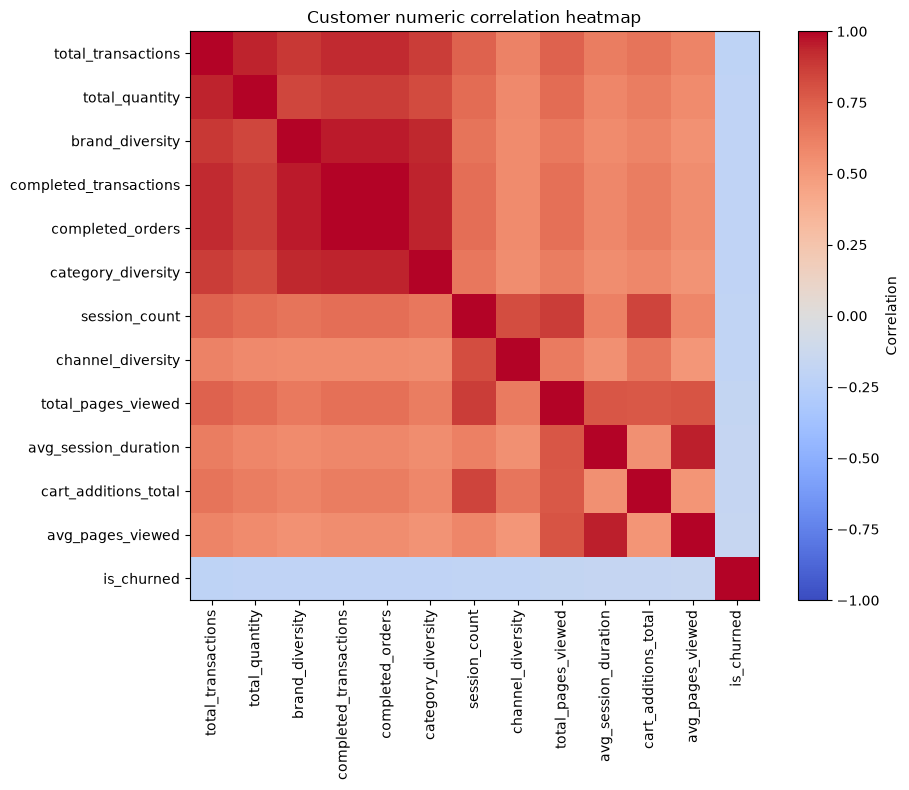

In [11]:
corr_cols = [
    c
    for c in CUSTOMER_NUMERIC_FEATURES
    if customer_model_df[c].nunique(dropna=True) > 1
]
corr_df = customer_model_df[corr_cols + [CUSTOMER_TARGET]].corr(numeric_only=True)
target_corr = (
    corr_df[CUSTOMER_TARGET]
    .drop(CUSTOMER_TARGET)
    .sort_values(key=lambda s: s.abs(), ascending=False)
)
display(target_corr.head(25).to_frame("corr_with_churn"))

top_corr_features = target_corr.abs().head(12).index.tolist()
plt.figure(figsize=(10, 8))
plt.imshow(
    customer_model_df[top_corr_features + [CUSTOMER_TARGET]].corr(),
    vmin=-1,
    vmax=1,
    cmap="coolwarm",
)
plt.colorbar(label="Correlation")
labels = top_corr_features + [CUSTOMER_TARGET]
plt.xticks(range(len(labels)), labels, rotation=90)
plt.yticks(range(len(labels)), labels)
plt.title("Customer numeric correlation heatmap")
plt.tight_layout()
plt.show()

**Nhận xét.** Correlation mạnh nhất với churn là `total_transactions` (-0.210), `total_quantity` (-0.200), `brand_diversity` (-0.200) và `completed_orders` (-0.198). Dấu âm cho thấy khách hoạt động nhiều hơn thường ít churn hơn trong dataset này.


---

### 13. Leakage analysis

Kiểm tra cột bị loại, giới hạn thời gian và target trong X.


In [12]:
leakage_report = {
    "prediction_cutoff": str(PREDICTION_CUTOFF),
    "target": CUSTOMER_TARGET,
    "excluded_from_X": [
        "customer_id",
        "product_id",
        "transaction_id",
        "session_id",
        "review_id",
        "signup_date",
        "transaction_date",
        "session_date",
        "review_date",
        "lifetime_value",
    ],
    "target_in_features": CUSTOMER_TARGET in CUSTOMER_FEATURES,
    "post_cutoff_rows_used": {
        "transactions": int(
            (transactions["transaction_date"] > PREDICTION_CUTOFF).sum()
        ),
        "sessions": int((sessions["session_date"] > PREDICTION_CUTOFF).sum()),
        "reviews": int((reviews["review_date"] > PREDICTION_CUTOFF).sum()),
    },
    "remaining_limitation": "is_churned is provided by dataset; churn date/outcome window is not reconstructable exactly",
}
print(json.dumps(leakage_report, indent=2, ensure_ascii=False))

{
  "prediction_cutoff": "2024-10-01 23:59:05",
  "target": "is_churned",
  "excluded_from_X": [
    "customer_id",
    "product_id",
    "transaction_id",
    "session_id",
    "review_id",
    "signup_date",
    "transaction_date",
    "session_date",
    "review_date",
    "lifetime_value"
  ],
  "target_in_features": false,
  "post_cutoff_rows_used": {
    "transactions": 14498,
    "sessions": 9861,
    "reviews": 3152
  },
  "remaining_limitation": "is_churned is provided by dataset; churn date/outcome window is not reconstructable exactly"
}


**Nhận xét.** Leakage report xác nhận `target_in_features=false`. Các dòng sau cutoff không dùng để tạo X, nhưng hạn chế còn lại là dataset không cung cấp `churn_date` để tái tạo outcome window chính xác.


---

### 14. Biểu diễn dữ liệu

Feature matrix gồm numeric aggregation, categorical preference/profile và review text representation.


In [13]:
X_customer = customer_model_df[CUSTOMER_FEATURES].copy()
y_customer = customer_model_df[CUSTOMER_TARGET].astype(int).copy()

display_df("One customer model row before sklearn preprocessing", X_customer, rows=1)
print("Feature matrix shape:", X_customer.shape)
print("Target shape:", y_customer.shape)
print("Numeric feature count:", len(CUSTOMER_NUMERIC_FEATURES))
print("Categorical feature count:", len(CUSTOMER_CATEGORICAL_FEATURES))
print("Text feature:", CUSTOMER_TEXT_FEATURE)

One customer model row before sklearn preprocessing


,age,email_opt_in,has_app,customer_tenure_days,total_transactions,total_quantity,avg_discount,avg_shipping_cost,completed_orders,total_spent,avg_order_value,category_diversity,brand_diversity,cancelled_transactions,completed_transactions,pending_transactions,refunded_transactions,session_count,avg_session_duration,total_pages_viewed,avg_pages_viewed,conversion_rate,bounce_rate,cart_additions_total,cart_additions_avg,device_diversity,channel_diversity,review_count,avg_rating,low_rating_share,verified_review_share,helpful_votes_total,days_since_last_transaction,days_since_last_session,days_since_last_review,spend_category_clothing,spend_category_electronics,spend_category_food_grocery,spend_category_health,spend_category_jewelry,spend_category_office_supplies,spend_category_pet_supplies,spend_category_sports,gender,country,segment,top_category,top_brand,top_device,top_channel,review_text_all
0,28,0,0,1692,22.0,29.0,5.227273,5.260455,15.0,649.36,43.290667,8.0,11.0,2.0,15.0,2.0,3.0,8.0,696.875,86.0,10.75,0.125,0.125,5.0,0.625,3.0,5.0,0.0,0.0,0.0,0.0,0.0,4.0,41.0,670.0,55.96,218.44,16.42,29.17,0.0,0.0,0.0,0.0,M,BR,Premium,Music,NovaTech,mobile,social,


Feature matrix shape: (10000, 51)
Target shape: (10000,)
Numeric feature count: 43
Categorical feature count: 7
Text feature: review_text_all


**Nhận xét.** X có 10,000 dòng và 51 feature trước preprocessing. Representation kết hợp profile, RFM, funnel, preference và text, nên giàu hơn dạng `load CSV -> drop null`.


---

### 15. Preprocessing pipeline

Numeric, categorical và text đi qua ba nhánh riêng trong ColumnTransformer.


In [14]:
customer_numeric_preprocess = Pipeline(
    [
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)

customer_categorical_preprocess = Pipeline(
    [
        ("imputer", SimpleImputer(strategy="constant", fill_value="Unknown")),
        ("onehot", make_one_hot_encoder(min_frequency=10)),
    ]
)

customer_text_preprocess = TfidfVectorizer(
    max_features=300,
    min_df=3,
    ngram_range=(1, 2),
    stop_words="english",
)

customer_preprocessor = ColumnTransformer(
    [
        ("numeric", customer_numeric_preprocess, CUSTOMER_NUMERIC_FEATURES),
        ("categorical", customer_categorical_preprocess, CUSTOMER_CATEGORICAL_FEATURES),
        ("text", customer_text_preprocess, CUSTOMER_TEXT_FEATURE),
    ],
    remainder="drop",
)

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_customer,
    y_customer,
    test_size=0.20,
    random_state=SEED,
    stratify=y_customer,
)

X_train_c_ready = customer_preprocessor.fit_transform(X_train_c)
X_test_c_ready = customer_preprocessor.transform(X_test_c)

print("Train target distribution:")
display(y_train_c.value_counts(normalize=True).sort_index().to_frame("train_pct"))
print("Test target distribution:")
display(y_test_c.value_counts(normalize=True).sort_index().to_frame("test_pct"))

Train target distribution:


,train_pct
is_churned,
0,0.830625
1,0.169375


Test target distribution:


,test_pct
is_churned,
0,0.8305
1,0.1695


**Nhận xét.** Sau preprocessing, train/test matrix có shape `(8000, 368)` và `(2000, 368)`. Số chiều tăng do one-hot categorical và TF-IDF text features.


---

### 16. Kiểm tra preprocessing

Xác nhận X/y hợp lệ, không có target leakage, split tạo được và transformed matrix không có NaN/Inf.


In [15]:
assert CUSTOMER_TARGET not in X_customer.columns
assert "lifetime_value" not in X_customer.columns
assert "customer_id" not in X_customer.columns
assert len(X_customer) == len(y_customer)
assert X_train_c_ready.shape[0] == len(y_train_c)
assert X_test_c_ready.shape[0] == len(y_test_c)
assert X_train_c_ready.shape[1] == X_test_c_ready.shape[1]

assert_no_nan_inf(X_train_c_ready, "X_train_c_ready")
assert_no_nan_inf(X_test_c_ready, "X_test_c_ready")

phase3_customer_summary = {
    "dataset_folder": str(CUSTOMER_DIR.relative_to(ROOT)),
    "target": CUSTOMER_TARGET,
    "task": "binary classification cho churn + diễn giải interest discovery",
    "rows": int(len(customer_model_df)),
    "numeric_feature_count": int(len(CUSTOMER_NUMERIC_FEATURES)),
    "categorical_feature_count": int(len(CUSTOMER_CATEGORICAL_FEATURES)),
    "text_feature": CUSTOMER_TEXT_FEATURE,
    "prediction_cutoff": str(PREDICTION_CUTOFF),
    "ready_for_modeling_and_packaging": [
        "Logistic Regression",
        "KNN",
        "Decision Tree",
        "Random Forest",
        "Gradient Boosting",
        "Teacher/Improved NumPy DL",
    ],
}
print(json.dumps(phase3_customer_summary, indent=2, ensure_ascii=False))

X_train_c_ready: shape=(8000, 368), finite_values=OK
X_test_c_ready: shape=(2000, 368), finite_values=OK
{
  "dataset_folder": "datasets\\customer_behavior",
  "target": "is_churned",
  "task": "binary classification cho churn + diễn giải interest discovery",
  "rows": 10000,
  "numeric_feature_count": 43,
  "categorical_feature_count": 7,
  "text_feature": "review_text_all",
  "prediction_cutoff": "2024-10-01 23:59:05",
  "ready_for_modeling_and_packaging": [
    "Logistic Regression",
    "KNN",
    "Decision Tree",
    "Random Forest",
    "Gradient Boosting",
    "Teacher/Improved NumPy DL"
  ]
}


---

### 17. Baseline và 5 mô hình ML

Huấn luyện 5 mô hình chính:

1. Logistic Regression
2. KNN
3. Decision Tree
4. Random Forest
5. Gradient Boosting


In [16]:
def safe_roc_auc(y_true, score):
    try:
        return roc_auc_score(y_true, score)
    except Exception:
        return np.nan


def classification_score_from_estimator(model, X):
    if hasattr(model, "predict_proba"):
        return model.predict_proba(X)[:, 1]
    if hasattr(model, "decision_function"):
        return model.decision_function(X)
    return model.predict(X)


def classification_metrics_row(name, y_true, y_pred, score):
    return {
        "Model": name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1": f1_score(y_true, y_pred, zero_division=0),
        "ROC-AUC": safe_roc_auc(y_true, score),
    }


def relu(x):
    return np.maximum(0, x)


def relu_derivative(x):
    return (x > 0).astype(float)


def sigmoid(x):
    x = np.clip(x, -50, 50)
    return 1.0 / (1.0 + np.exp(-x))


def binary_cross_entropy(y_true, y_prob, sample_weight=None, eps=1e-8):
    y_true = y_true.reshape(-1, 1)
    y_prob = np.clip(y_prob, eps, 1 - eps)
    per_sample = -(y_true * np.log(y_prob) + (1 - y_true) * np.log(1 - y_prob))
    if sample_weight is None:
        return float(np.mean(per_sample))
    weights = sample_weight.reshape(-1, 1)
    return float(np.sum(per_sample * weights) / np.sum(weights))


def teacher_forward_binary(X, params):
    z1 = X @ params["W1"] + params["b1"]
    h1 = relu(z1)
    z2 = h1 @ params["W2"] + params["b2"]
    h2 = relu(z2)
    z3 = h2 @ params["W3"] + params["b3"]
    y_hat = sigmoid(z3)
    cache = {"X": X, "z1": z1, "h1": h1, "z2": z2, "h2": h2, "z3": z3, "y_hat": y_hat}
    return y_hat, cache


def train_teacher_binary_dnn(
    X_train, y_train, input_dim, epochs=1000, learning_rate=0.01, seed=42
):
    rng = np.random.default_rng(seed)
    y_train = y_train.reshape(-1, 1)
    params = {
        "W1": rng.normal(size=(input_dim, 16)) * np.sqrt(2.0 / input_dim),
        "b1": np.zeros((1, 16)),
        "W2": rng.normal(size=(16, 8)) * np.sqrt(2.0 / 16),
        "b2": np.zeros((1, 8)),
        "W3": rng.normal(size=(8, 1)) * np.sqrt(2.0 / 8),
        "b3": np.zeros((1, 1)),
    }
    losses = []
    for epoch in range(epochs):
        y_hat, cache = teacher_forward_binary(X_train, params)
        losses.append(binary_cross_entropy(y_train, y_hat))

        n = len(X_train)
        dz3 = (y_hat - y_train) / n
        dW3 = cache["h2"].T @ dz3
        db3 = np.sum(dz3, axis=0, keepdims=True)
        dh2 = dz3 @ params["W3"].T
        dz2 = dh2 * relu_derivative(cache["z2"])
        dW2 = cache["h1"].T @ dz2
        db2 = np.sum(dz2, axis=0, keepdims=True)
        dh1 = dz2 @ params["W2"].T
        dz1 = dh1 * relu_derivative(cache["z1"])
        dW1 = cache["X"].T @ dz1
        db1 = np.sum(dz1, axis=0, keepdims=True)

        params["W3"] -= learning_rate * dW3
        params["b3"] -= learning_rate * db3
        params["W2"] -= learning_rate * dW2
        params["b2"] -= learning_rate * db2
        params["W1"] -= learning_rate * dW1
        params["b1"] -= learning_rate * db1
    return params, losses


def improved_forward_binary(X, params):
    z1 = X @ params["W1"] + params["b1"]
    h1 = relu(z1)
    z2 = h1 @ params["W2"] + params["b2"]
    h2 = relu(z2)
    z3 = h2 @ params["W3"] + params["b3"]
    y_hat = sigmoid(z3)
    cache = {"X": X, "z1": z1, "h1": h1, "z2": z2, "h2": h2, "z3": z3, "y_hat": y_hat}
    return y_hat, cache


def train_improved_binary_dnn(
    X_train,
    y_train,
    X_val,
    y_val,
    hidden=(64, 32),
    epochs=300,
    learning_rate=0.01,
    batch_size=512,
    l2=1e-4,
    class_weight=None,
    patience=25,
    seed=42,
):
    rng = np.random.default_rng(seed)
    input_dim = X_train.shape[1]
    h1, h2 = hidden
    y_train = y_train.reshape(-1, 1)
    y_val = y_val.reshape(-1, 1)
    params = {
        "W1": rng.normal(size=(input_dim, h1)) * np.sqrt(2.0 / input_dim),
        "b1": np.zeros((1, h1)),
        "W2": rng.normal(size=(h1, h2)) * np.sqrt(2.0 / h1),
        "b2": np.zeros((1, h2)),
        "W3": rng.normal(size=(h2, 1)) * np.sqrt(2.0 / h2),
        "b3": np.zeros((1, 1)),
    }
    sample_weight = None
    if class_weight is not None:
        sample_weight = np.array(
            [class_weight[int(v)] for v in y_train.ravel()], dtype=float
        )

    history = {"train_loss": [], "val_loss": []}
    best_params = {k: v.copy() for k, v in params.items()}
    best_val = np.inf
    wait = 0

    for epoch in range(epochs):
        indices = rng.permutation(len(X_train))
        for start in range(0, len(indices), batch_size):
            batch_idx = indices[start : start + batch_size]
            xb = X_train[batch_idx]
            yb = y_train[batch_idx]
            wb = sample_weight[batch_idx] if sample_weight is not None else None
            y_hat, cache = improved_forward_binary(xb, params)
            if wb is None:
                dz3 = (y_hat - yb) / len(xb)
            else:
                dz3 = (y_hat - yb) * wb.reshape(-1, 1) / np.sum(wb)

            dW3 = cache["h2"].T @ dz3 + l2 * params["W3"] / len(xb)
            db3 = np.sum(dz3, axis=0, keepdims=True)
            dh2 = dz3 @ params["W3"].T
            dz2 = dh2 * relu_derivative(cache["z2"])
            dW2 = cache["h1"].T @ dz2 + l2 * params["W2"] / len(xb)
            db2 = np.sum(dz2, axis=0, keepdims=True)
            dh1 = dz2 @ params["W2"].T
            dz1 = dh1 * relu_derivative(cache["z1"])
            dW1 = cache["X"].T @ dz1 + l2 * params["W1"] / len(xb)
            db1 = np.sum(dz1, axis=0, keepdims=True)

            params["W3"] -= learning_rate * dW3
            params["b3"] -= learning_rate * db3
            params["W2"] -= learning_rate * dW2
            params["b2"] -= learning_rate * db2
            params["W1"] -= learning_rate * dW1
            params["b1"] -= learning_rate * db1

        train_prob, _ = improved_forward_binary(X_train, params)
        val_prob, _ = improved_forward_binary(X_val, params)
        train_loss = binary_cross_entropy(
            y_train, train_prob, sample_weight=sample_weight
        )
        val_loss = binary_cross_entropy(y_val, val_prob)
        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)

        if val_loss < best_val - 1e-5:
            best_val = val_loss
            best_params = {k: v.copy() for k, v in params.items()}
            wait = 0
        else:
            wait += 1
            if wait >= patience:
                break

    return best_params, history


def tune_threshold_by_f1(y_true, prob):
    rows = []
    for threshold in np.linspace(0.2, 0.8, 61):
        pred = (prob >= threshold).astype(int)
        rows.append(
            {"threshold": threshold, "f1": f1_score(y_true, pred, zero_division=0)}
        )
    table = pd.DataFrame(rows)
    best = table.sort_values("f1", ascending=False).iloc[0]
    return float(best["threshold"]), table


customer_reference_baseline = DummyClassifier(strategy="most_frequent")
customer_reference_baseline.fit(X_train_c, y_train_c)
baseline_pred_c = customer_reference_baseline.predict(X_test_c)
customer_baseline_metrics = pd.DataFrame(
    [
        classification_metrics_row(
            "Reference Baseline - Most Frequent",
            y_test_c,
            baseline_pred_c,
            baseline_pred_c,
        )
    ]
)
display(customer_baseline_metrics.round(4))


def customer_model_pipeline(estimator):
    return Pipeline(
        [
            ("preprocessor", clone(customer_preprocessor)),
            ("dense", dense_transformer()),
            ("model", estimator),
        ]
    )


customer_ml_models = {
    "Logistic Regression": customer_model_pipeline(
        LogisticRegression(max_iter=1000, class_weight="balanced", random_state=SEED)
    ),
    "KNN": customer_model_pipeline(
        KNeighborsClassifier(n_neighbors=15, weights="distance", n_jobs=-1)
    ),
    "Decision Tree": customer_model_pipeline(
        DecisionTreeClassifier(
            max_depth=10,
            min_samples_leaf=30,
            class_weight="balanced",
            random_state=SEED,
        )
    ),
    "Random Forest": customer_model_pipeline(
        RandomForestClassifier(
            n_estimators=160,
            min_samples_leaf=8,
            class_weight="balanced",
            random_state=SEED,
            n_jobs=-1,
        )
    ),
    "Gradient Boosting": customer_model_pipeline(
        GradientBoostingClassifier(
            n_estimators=140, learning_rate=0.06, max_depth=3, random_state=SEED
        )
    ),
}

customer_ml_rows = []
customer_overfit_rows = []
fitted_customer_ml_models = {}
for name, model in customer_ml_models.items():
    model.fit(X_train_c, y_train_c)
    fitted_customer_ml_models[name] = model
    y_pred = model.predict(X_test_c)
    y_score = classification_score_from_estimator(model, X_test_c)
    customer_ml_rows.append(classification_metrics_row(name, y_test_c, y_pred, y_score))

    train_pred = model.predict(X_train_c)
    customer_overfit_rows.append(
        {
            "Model": name,
            "Train F1": f1_score(y_train_c, train_pred, zero_division=0),
            "Test F1": f1_score(y_test_c, y_pred, zero_division=0),
            "Gap": f1_score(y_train_c, train_pred, zero_division=0)
            - f1_score(y_test_c, y_pred, zero_division=0),
        }
    )

customer_ml_results = (
    pd.DataFrame(customer_ml_rows)
    .sort_values("F1", ascending=False)
    .reset_index(drop=True)
)
customer_overfit_table = pd.DataFrame(customer_overfit_rows).sort_values(
    "Gap", ascending=False
)
display(customer_ml_results.round(4))
display(customer_overfit_table.round(4))

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Reference Baseline - Most Frequent,0.8305,0.0,0.0,0.0,0.5


,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Logistic Regression,0.6385,0.2551,0.5900,0.3562,0.6627
1,Random Forest,0.6980,0.2788,0.4926,0.3561,0.6792
2,Decision Tree,0.6030,0.2333,0.5870,0.3339,0.6236
3,KNN,0.8225,0.2778,0.0295,0.0533,0.6174
4,Gradient Boosting,0.8290,0.2857,0.0059,0.0116,0.6745


,Model,Train F1,Test F1,Gap
1,KNN,1.0000,0.0533,0.9467
3,Random Forest,0.7051,0.3561,0.3490
2,Decision Tree,0.4489,0.3339,0.1150
4,Gradient Boosting,0.0629,0.0116,0.0513
0,Logistic Regression,0.4060,0.3562,0.0498


**Nhận xét.** Logistic Regression là ML tốt nhất theo F1 (0.358), còn Random Forest có ROC-AUC cao nhất trong nhóm ML (0.679). KNN đạt Accuracy cao 0.823 nhưng F1 chỉ 0.053, cho thấy Accuracy không phù hợp với churn imbalance.


---

### 18. DL baseline theo mã mẫu giảng viên

Baseline giữ NumPy-only, kiến trúc `input -> 16 -> 8 -> 1`, ReLU/ReLU/Sigmoid, BCE, full-batch gradient descent, learning rate `0.01` và `1000` epochs.


,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Teacher DL Baseline,0.8305,0.0,0.0,0.0,0.6597


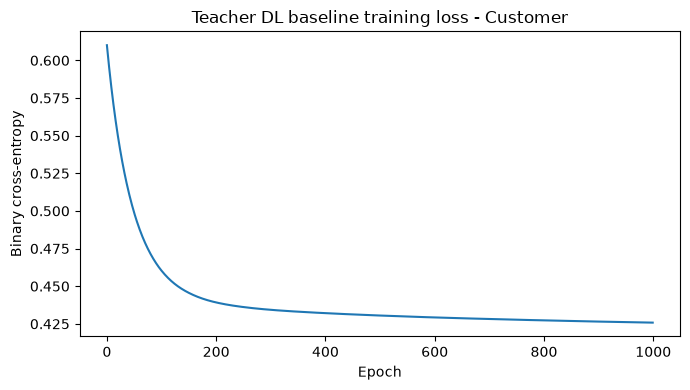

In [17]:
X_train_c_dense = to_dense_array(X_train_c_ready)
X_test_c_dense = to_dense_array(X_test_c_ready)
y_train_c_np = y_train_c.to_numpy().astype(int)
y_test_c_np = y_test_c.to_numpy().astype(int)

teacher_customer_params, teacher_customer_loss = train_teacher_binary_dnn(
    X_train_c_dense,
    y_train_c_np,
    input_dim=X_train_c_dense.shape[1],
    epochs=1000,
    learning_rate=0.01,
    seed=SEED,
)
teacher_customer_prob, _ = teacher_forward_binary(
    X_test_c_dense, teacher_customer_params
)
teacher_customer_prob = teacher_customer_prob.ravel()
teacher_customer_pred = (teacher_customer_prob >= 0.5).astype(int)
teacher_customer_metrics = pd.DataFrame(
    [
        classification_metrics_row(
            "Teacher DL Baseline",
            y_test_c_np,
            teacher_customer_pred,
            teacher_customer_prob,
        )
    ]
)
display(teacher_customer_metrics.round(4))

if HAS_MATPLOTLIB:
    plt.figure(figsize=(7, 4))
    plt.plot(teacher_customer_loss)
    plt.title("Teacher DL baseline training loss - Customer")
    plt.xlabel("Epoch")
    plt.ylabel("Binary cross-entropy")
    plt.tight_layout()
    plt.show()

**Nhận xét.** DL baseline đạt Accuracy 0.831 nhưng F1 = 0 vì dự đoán không bắt được churner ở threshold 0.5. Đây là ví dụ rõ về việc Accuracy bị lệch do class imbalance.


---

### 19. Improved DNN

Improved DNN thêm validation split, hidden layers lớn hơn, mini-batch, L2 regularization, early stopping, class-weighted BCE và threshold tuning.


Class weights: {0: np.float64(0.6019563581640331), 1: np.float64(2.952029520295203)}
Selected validation threshold: 0.49


,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Improved DNN,0.611,0.252,0.6578,0.3644,0.6655


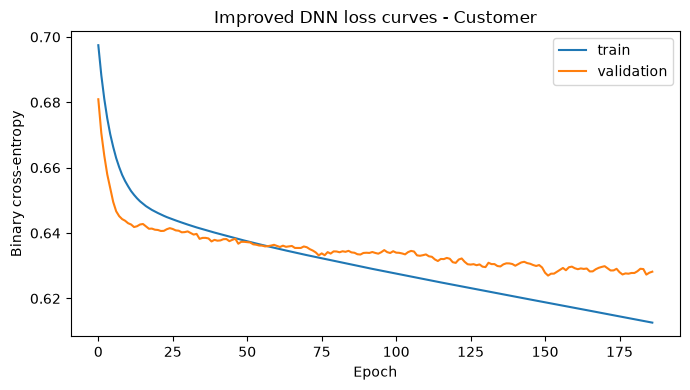

In [18]:
X_c_train_nn, X_c_val_nn, y_c_train_nn, y_c_val_nn = train_test_split(
    X_train_c_dense,
    y_train_c_np,
    test_size=0.20,
    random_state=SEED,
    stratify=y_train_c_np,
)

class_counts_c = np.bincount(y_c_train_nn)
class_weight_c = {
    0: len(y_c_train_nn) / (2 * class_counts_c[0]),
    1: len(y_c_train_nn) / (2 * class_counts_c[1]),
}

improved_customer_params, improved_customer_history = train_improved_binary_dnn(
    X_c_train_nn,
    y_c_train_nn,
    X_c_val_nn,
    y_c_val_nn,
    hidden=(64, 32),
    epochs=320,
    learning_rate=0.01,
    batch_size=512,
    l2=1e-4,
    class_weight=class_weight_c,
    patience=35,
    seed=SEED,
)

val_prob_c, _ = improved_forward_binary(X_c_val_nn, improved_customer_params)
val_prob_c = val_prob_c.ravel()
best_threshold_c, threshold_table_c = tune_threshold_by_f1(y_c_val_nn, val_prob_c)

improved_customer_prob, _ = improved_forward_binary(
    X_test_c_dense, improved_customer_params
)
improved_customer_prob = improved_customer_prob.ravel()
improved_customer_pred = (improved_customer_prob >= best_threshold_c).astype(int)
improved_customer_row = classification_metrics_row(
    "Improved DNN", y_test_c_np, improved_customer_pred, improved_customer_prob
)

print("Class weights:", class_weight_c)
print("Selected validation threshold:", round(best_threshold_c, 3))
display(pd.DataFrame([improved_customer_row]).round(4))

if HAS_MATPLOTLIB:
    plt.figure(figsize=(7, 4))
    plt.plot(improved_customer_history["train_loss"], label="train")
    plt.plot(improved_customer_history["val_loss"], label="validation")
    plt.title("Improved DNN loss curves - Customer")
    plt.xlabel("Epoch")
    plt.ylabel("Binary cross-entropy")
    plt.legend()
    plt.tight_layout()
    plt.show()

**Nhận xét.** Improved DNN đạt Recall = 0.658 và F1 = 0.364, tăng mạnh so với baseline F1 = 0. Tuy Precision chỉ 0.252, model chấp nhận nhiều false positives để bắt churner tốt hơn.


---

### 20. So sánh DL

So sánh DL baseline của giảng viên với Improved DNN.


In [19]:
customer_dl_comparison = pd.concat(
    [teacher_customer_metrics, pd.DataFrame([improved_customer_row])],
    ignore_index=True,
)
display(customer_dl_comparison.round(4))

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Teacher DL Baseline,0.8305,0.000,0.0000,0.0000,0.6597
1,Improved DNN,0.6110,0.252,0.6578,0.3644,0.6655


---

### 21. So sánh 6 mô hình cuối

Bảng cuối gồm 5 mô hình ML và Improved DNN.


,Model,Accuracy,Precision,Recall,F1,ROC-AUC
5,Improved DNN,0.6110,0.2520,0.6578,0.3644,0.6655
0,Logistic Regression,0.6385,0.2551,0.5900,0.3562,0.6627
1,Random Forest,0.6980,0.2788,0.4926,0.3561,0.6792
2,Decision Tree,0.6030,0.2333,0.5870,0.3339,0.6236
3,KNN,0.8225,0.2778,0.0295,0.0533,0.6174
4,Gradient Boosting,0.8290,0.2857,0.0059,0.0116,0.6745


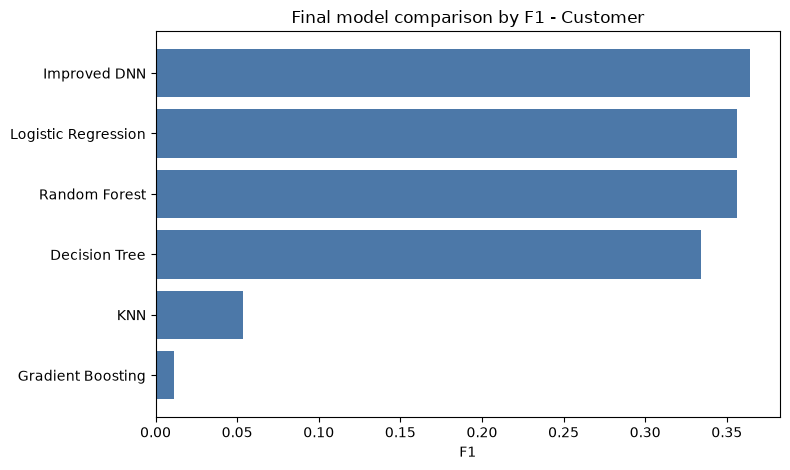

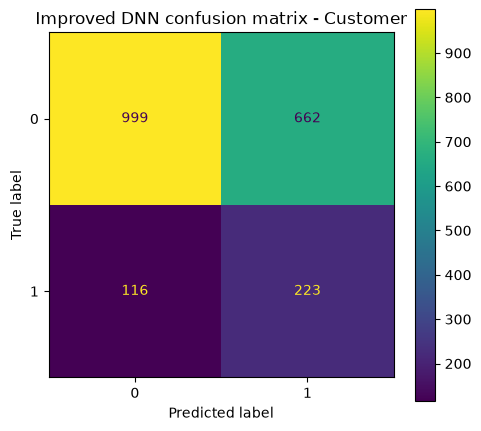

In [20]:
final_customer_comparison = pd.concat(
    [customer_ml_results, pd.DataFrame([improved_customer_row])],
    ignore_index=True,
)
final_customer_comparison = final_customer_comparison[
    ["Model", "Accuracy", "Precision", "Recall", "F1", "ROC-AUC"]
]
assert len(final_customer_comparison) == 6
assert "Teacher DL Baseline" not in final_customer_comparison["Model"].tolist()
display(final_customer_comparison.sort_values("F1", ascending=False).round(4))

if HAS_MATPLOTLIB:
    chart_df = final_customer_comparison.sort_values("F1")
    plt.figure(figsize=(8, 4.8))
    plt.barh(chart_df["Model"], chart_df["F1"], color="#4C78A8")
    plt.xlabel("F1")
    plt.title("Final model comparison by F1 - Customer")
    plt.tight_layout()
    plt.show()

    cm = confusion_matrix(y_test_c_np, improved_customer_pred)
    fig, ax = plt.subplots(figsize=(5, 4.5))
    ConfusionMatrixDisplay(cm, display_labels=[0, 1]).plot(ax=ax, values_format="d")
    ax.set_title("Improved DNN confusion matrix - Customer")
    plt.tight_layout()
    plt.show()

**Nhận xét.** Improved DNN là model tốt nhất theo F1 (0.364), chỉ nhỉnh hơn Logistic Regression (0.358). Random Forest vẫn có ROC-AUC cao hơn (0.679 so với 0.665), nên lựa chọn cuối phụ thuộc ưu tiên F1 hay ranking quality.


In [21]:
best_customer_row = final_customer_comparison.sort_values("F1", ascending=False).iloc[0]
print("Best final customer model:", best_customer_row["Model"])
print("Primary metric F1:", round(float(best_customer_row["F1"]), 4))
print(
    "Did Improved DNN beat all classical ML by F1?:",
    bool(best_customer_row["Model"] == "Improved DNN"),
)

Best final customer model: Improved DNN
Primary metric F1: 0.3644
Did Improved DNN beat all classical ML by F1?: True


---

### 22. Đóng gói pipeline

Lưu model tốt nhất, preprocessor, metadata, feature schema, demo input và demo prediction. Artifact được load lại để kiểm tra inference.


In [22]:
PIPELINE_ARTIFACT_DIR = ROOT / "pipeline" / "customer_behavior"
PIPELINE_ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)


def json_safe(value):
    if isinstance(value, dict):
        return {str(k): json_safe(v) for k, v in value.items()}
    if isinstance(value, (list, tuple)):
        return [json_safe(v) for v in value]
    if isinstance(value, np.ndarray):
        return value.tolist()
    if isinstance(value, (np.integer,)):
        return int(value)
    if isinstance(value, (np.floating,)):
        return float(value)
    if isinstance(value, (np.bool_,)):
        return bool(value)
    try:
        if pd.isna(value):
            return None
    except (TypeError, ValueError):
        pass
    return value


def write_json(path, payload):
    path.write_text(
        json.dumps(json_safe(payload), indent=2, ensure_ascii=False), encoding="utf-8"
    )


def relative_path(path):
    return str(Path(path).relative_to(ROOT)).replace("\\", "/")


def metrics_from_row(row, columns):
    return {col: json_safe(row[col]) for col in columns}


def customer_unit_for_feature(name):
    if "days_since" in name or name == "customer_tenure_days":
        return "days"
    if "duration" in name:
        return "seconds"
    if name.endswith("_rate") or name.endswith("_share"):
        return "proportion"
    if any(
        token in name for token in ["spent", "order_value", "shipping_cost", "discount"]
    ):
        return "source monetary amount"
    if any(
        token in name
        for token in [
            "count",
            "orders",
            "transactions",
            "quantity",
            "pages",
            "cart_additions",
            "diversity",
            "votes",
        ]
    ):
        return "count"
    return None


CUSTOMER_METRIC_COLUMNS = ["Accuracy", "Precision", "Recall", "F1", "ROC-AUC"]
assert len(final_customer_comparison) == 6
assert "Teacher DL Baseline" not in final_customer_comparison["Model"].tolist()

best_customer_row = final_customer_comparison.sort_values("F1", ascending=False).iloc[0]
selected_customer_model = str(best_customer_row["Model"])

model_path = PIPELINE_ARTIFACT_DIR / (
    "model.npz" if selected_customer_model == "Improved DNN" else "model.joblib"
)
preprocessor_path = PIPELINE_ARTIFACT_DIR / "preprocessor.joblib"
metadata_path = PIPELINE_ARTIFACT_DIR / "metadata.json"
schema_path = PIPELINE_ARTIFACT_DIR / "feature_schema.json"
demo_input_path = PIPELINE_ARTIFACT_DIR / "demo_input.json"
demo_prediction_path = PIPELINE_ARTIFACT_DIR / "demo_prediction.json"
final_table_path = PIPELINE_ARTIFACT_DIR / "final_comparison.csv"
dl_table_path = PIPELINE_ARTIFACT_DIR / "dl_comparison.csv"

if selected_customer_model == "Improved DNN":
    np.savez(model_path, **improved_customer_params)
    joblib.dump(customer_preprocessor, preprocessor_path)
    model_format = "NumPy DNN weights (.npz) + joblib ColumnTransformer"
    decision_threshold = float(best_threshold_c)
else:
    selected_pipeline = fitted_customer_ml_models[selected_customer_model]
    joblib.dump(selected_pipeline, model_path)
    joblib.dump(
        selected_pipeline.named_steps.get("preprocessor", customer_preprocessor),
        preprocessor_path,
    )
    model_format = "joblib sklearn Pipeline"
    decision_threshold = None

final_customer_comparison.to_csv(final_table_path, index=False)
customer_dl_comparison.to_csv(dl_table_path, index=False)

customer_schema_features = []
for name in CUSTOMER_FEATURES:
    if name in CUSTOMER_NUMERIC_FEATURES:
        customer_schema_features.append(
            {
                "name": name,
                "type": "number",
                "required": True,
                "allowed_or_category_notes": "Numeric customer-level aggregate available at prediction time.",
                "unit": customer_unit_for_feature(name),
                "description": "Customer profile or pre-cutoff behavior aggregate.",
            }
        )
    elif name in CUSTOMER_CATEGORICAL_FEATURES:
        customer_schema_features.append(
            {
                "name": name,
                "type": "string",
                "required": True,
                "allowed_or_category_notes": "Seen training categories are encoded; unseen values are ignored safely by OneHotEncoder.",
                "unit": None,
                "description": "Customer profile or dominant pre-cutoff preference category.",
            }
        )
    else:
        customer_schema_features.append(
            {
                "name": name,
                "type": "string",
                "required": True,
                "allowed_or_category_notes": "Use an empty string when no review text is available.",
                "unit": None,
                "description": "Concatenated pre-cutoff review text represented by TF-IDF.",
            }
        )

customer_feature_schema = {
    "task_name": "Customer Behavior Churn Classification",
    "target": CUSTOMER_TARGET,
    "prediction_time_input": "One customer-level feature row built only from information available before the prediction cutoff.",
    "prediction_cutoff": str(PREDICTION_CUTOFF),
    "feature_order": CUSTOMER_FEATURES,
    "features": customer_schema_features,
}

customer_metadata = {
    "task_name": "Customer Behavior Churn Classification",
    "task_type": "binary_classification",
    "dataset_name": "Synthetic E-Commerce Customer Behavior Dataset",
    "dataset_path": relative_path(CUSTOMER_DIR),
    "target": CUSTOMER_TARGET,
    "selected_model": selected_customer_model,
    "selection_metric": "F1",
    "metrics": metrics_from_row(best_customer_row, CUSTOMER_METRIC_COLUMNS),
    "feature_count": int(len(CUSTOMER_FEATURES)),
    "numeric_feature_count": int(len(CUSTOMER_NUMERIC_FEATURES)),
    "categorical_feature_count": int(len(CUSTOMER_CATEGORICAL_FEATURES)),
    "text_feature": CUSTOMER_TEXT_FEATURE,
    "transformed_feature_count": int(X_train_c_ready.shape[1]),
    "training_date": datetime.now(timezone.utc).replace(microsecond=0).isoformat(),
    "preprocessing_summary": "Numeric median imputation + scaling; categorical Unknown imputation + one-hot encoding; review text TF-IDF. All fitted on training split only.",
    "target_transformation": None,
    "model_format": model_format,
    "model_file": relative_path(model_path),
    "preprocessor_file": relative_path(preprocessor_path),
    "decision_threshold": decision_threshold,
    "class_weight": (
        json_safe(class_weight_c) if "class_weight_c" in globals() else None
    ),
    "prediction_cutoff": str(PREDICTION_CUTOFF),
    "notes": [
        "Features are built from pre-cutoff behavior to reduce future-information leakage.",
        "The dataset supplies is_churned without an exact churn date, so the outcome-window limitation remains documented.",
    ],
}

demo_input = {col: json_safe(X_customer.iloc[0][col]) for col in CUSTOMER_FEATURES}
assert CUSTOMER_TARGET not in demo_input
assert "customer_id" not in demo_input
assert "lifetime_value" not in demo_input

write_json(metadata_path, customer_metadata)
write_json(schema_path, customer_feature_schema)
write_json(demo_input_path, demo_input)

demo_df = pd.DataFrame([demo_input], columns=CUSTOMER_FEATURES)
if selected_customer_model == "Improved DNN":
    loaded_preprocessor = joblib.load(preprocessor_path)
    demo_ready = to_dense_array(loaded_preprocessor.transform(demo_df))
    with np.load(model_path) as loaded:
        loaded_params = {key: loaded[key] for key in loaded.files}
    demo_prob, _ = improved_forward_binary(demo_ready, loaded_params)
    probability = float(demo_prob.ravel()[0])
    demo_prediction = {
        "model": selected_customer_model,
        "probability_class_1": probability,
        "predicted_class": int(probability >= decision_threshold),
        "threshold": decision_threshold,
    }
else:
    loaded_model = joblib.load(model_path)
    demo_prediction = {
        "model": selected_customer_model,
        "predicted_class": int(loaded_model.predict(demo_df)[0]),
    }
    if hasattr(loaded_model, "predict_proba"):
        demo_prediction["probability_class_1"] = float(
            loaded_model.predict_proba(demo_df)[:, 1][0]
        )
    elif hasattr(loaded_model, "decision_function"):
        demo_prediction["decision_score"] = float(
            loaded_model.decision_function(demo_df)[0]
        )

write_json(demo_prediction_path, demo_prediction)

for json_path in [metadata_path, schema_path, demo_input_path, demo_prediction_path]:
    json.loads(json_path.read_text(encoding="utf-8"))
for path in [
    model_path,
    preprocessor_path,
    metadata_path,
    schema_path,
    demo_input_path,
    demo_prediction_path,
    final_table_path,
    dl_table_path,
]:
    assert path.exists(), f"Missing artifact: {path}"

display(pd.DataFrame([demo_prediction]))
print("Saved customer-behavior artifacts:")
for path in sorted(PIPELINE_ARTIFACT_DIR.iterdir()):
    print("-", relative_path(path))

,model,probability_class_1,predicted_class,threshold
0,Improved DNN,0.172461,0,0.49


Saved customer-behavior artifacts:
- pipeline/customer_behavior/demo_input.json
- pipeline/customer_behavior/demo_prediction.json
- pipeline/customer_behavior/dl_comparison.csv
- pipeline/customer_behavior/feature_schema.json
- pipeline/customer_behavior/final_comparison.csv
- pipeline/customer_behavior/metadata.json
- pipeline/customer_behavior/model.npz
- pipeline/customer_behavior/preprocessor.joblib
